In [131]:
# ============================================================
# EstateVision AI - House Price Prediction
# Part 1: Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import json
import pickle

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    ShuffleSplit,
    GridSearchCV,
    cross_val_score
)

# Regression Models
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

# Evaluation Metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [132]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("../../datasets/Bengaluru_House_Data_Final.csv")

print("✅ Dataset Loaded Successfully")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

✅ Dataset Loaded Successfully
Rows    : 7264
Columns : 11


In [ ]:
# First 5 rows

df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
0,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,1875.0,3.0,1.0,167.0,3,8906.666667,625.000000
1,Built-up Area,Ready To Move,1st Phase JP Nagar,5 Bedroom,1500.0,5.0,2.0,85.0,5,5666.666667,300.000000
2,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2065.0,4.0,1.0,210.0,3,10169.491525,688.333333
3,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2059.0,3.0,2.0,225.0,3,10927.634774,686.333333
4,Super built-up Area,Ready To Move,1st Phase JP Nagar,2 BHK,1394.0,2.0,1.0,100.0,2,7173.601148,697.000000


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7264 entries, 0 to 7263
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       7264 non-null   object 
 1   availability    7264 non-null   object 
 2   location        7264 non-null   object 
 3   size            7264 non-null   object 
 4   total_sqft      7264 non-null   float64
 5   bath            7264 non-null   float64
 6   balcony         7264 non-null   float64
 7   price           7264 non-null   float64
 8   bhk             7264 non-null   int64  
 9   price_per_sqft  7264 non-null   float64
 10  sqft_per_bhk    7264 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 624.4+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_sqft,7264.0,1490.099531,856.133710,300.0,1095.000000,1257.500000,1670.000000,30000.0
bath,7264.0,2.448238,1.008196,1.0,2.000000,2.000000,3.000000,16.0
balcony,7264.0,1.562087,0.780634,0.0,1.000000,2.000000,2.000000,3.0
price,7264.0,98.408209,92.162043,10.0,50.000000,73.430000,112.000000,2200.0
bhk,7264.0,2.495182,0.920780,1.0,2.000000,2.000000,3.000000,16.0
price_per_sqft,7264.0,6118.131711,2359.939368,1300.0,4595.970046,5698.774946,6910.712558,24000.0
sqft_per_bhk,7264.0,596.384631,227.494958,300.0,505.500000,575.000000,638.500000,10030.0


In [ ]:
# Missing values in each column

missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 368


In [ ]:
df = df.drop_duplicates()

print("Remaining Rows :", len(df))

Remaining Rows : 6896


In [ ]:
print("Columns\n")
print(df.columns.tolist())

Columns

['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath', 'balcony', 'price', 'bhk', 'price_per_sqft', 'sqft_per_bhk']


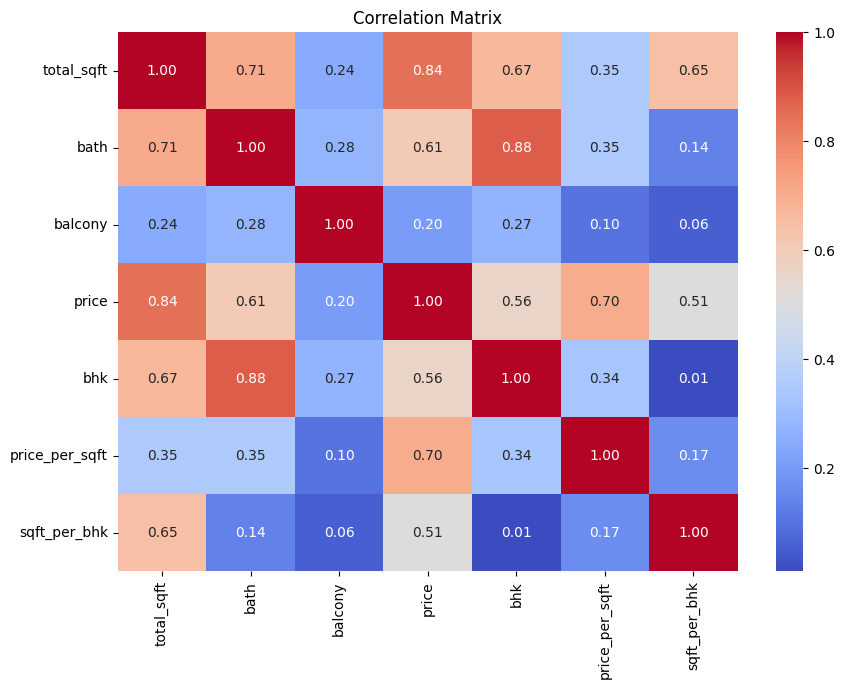

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

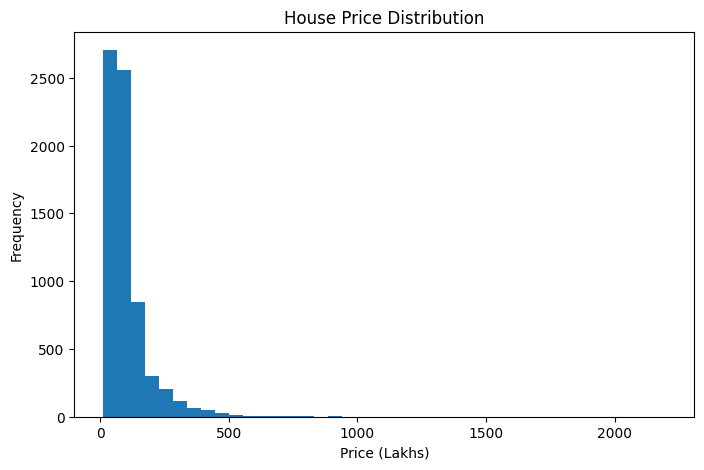

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=40)

plt.title("House Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# ============================================================
# Drop Unnecessary Columns
# ============================================================

df_model = df.copy()

# Drop only unnecessary columns
columns_to_drop = [
    "size",
    "price_per_sqft"   # Remove because it causes data leakage
]

df_model.drop(columns=columns_to_drop, inplace=True)

print("Remaining Columns:")
print(df_model.columns.tolist())

print("\nShape after dropping columns:")
print(df_model.shape)

Remaining Columns:
['area_type', 'availability', 'location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk', 'sqft_per_bhk']

Shape after dropping columns:
(6896, 9)


In [ ]:
# ============================================================
# Missing Values
# ============================================================

missing = df_model.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ No Missing Values Found")
else:
    print(missing)

✅ No Missing Values Found


In [ ]:
# ============================================================
# Top Locations
# ============================================================

location_count = df_model.location.value_counts()

print(location_count.head(20))

location
other                       1173
Whitefield                   234
Sarjapur  Road               184
Electronic City              157
Raja Rajeshwari Nagar        130
Marathahalli                 112
Thanisandra                  107
Bannerghatta Road            106
Uttarahalli                  103
Hennur Road                  102
Hebbal                        96
Electronic City Phase II      88
Yelahanka                     85
7th Phase JP Nagar            81
Haralur Road                  79
Kanakpura Road                77
Bellandur                     71
KR Puram                      63
Harlur                        58
Sarjapur                      58
Name: count, dtype: int64


In [ ]:
# ============================================================
# Group Rare Locations
# ============================================================

location_count = df_model.location.value_counts()

rare_locations = location_count[location_count <= 10].index

df_model.location = df_model.location.apply(
    lambda x: "other" if x in rare_locations else x
)

print("Unique Locations :", df_model.location.nunique())

Unique Locations : 168


In [ ]:
# ============================================================
# One Hot Encoding
# ============================================================

dummies = pd.get_dummies(df_model.location)

print("Dummy Variables Created :", dummies.shape[1])

Dummy Variables Created : 168


In [ ]:
# ============================================================
# Remove Dummy Trap
# ============================================================

if "other" in dummies.columns:
    dummies.drop(columns=["other"], inplace=True)

print(dummies.head())

   1st Phase JP Nagar  5th Phase JP Nagar  6th Phase JP Nagar  \
0                True               False               False   
1                True               False               False   
2                True               False               False   
3                True               False               False   
4                True               False               False   

   7th Phase JP Nagar  8th Phase JP Nagar  9th Phase JP Nagar  Abbigere  \
0               False               False               False     False   
1               False               False               False     False   
2               False               False               False     False   
3               False               False               False     False   
4               False               False               False     False   

   Akshaya Nagar  Ambalipura  Ambedkar Nagar  ...  Uttarahalli  Varthur  \
0          False       False           False  ...        False    False   
1       

In [ ]:
# ============================================================
# Merge Encoded Columns
# ============================================================

df_model = pd.concat(
    [df_model, dummies],
    axis=1
)

df_model.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,sqft_per_bhk,1st Phase JP Nagar,...,Uttarahalli,Varthur,Vidyaranyapura,Vijayanagar,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,Super built-up Area,Ready To Move,1st Phase JP Nagar,1875.0,3.0,1.0,167.0,3,625.000000,True,...,False,False,False,False,False,False,False,False,False,False
1,Built-up Area,Ready To Move,1st Phase JP Nagar,1500.0,5.0,2.0,85.0,5,300.000000,True,...,False,False,False,False,False,False,False,False,False,False
2,Super built-up Area,Ready To Move,1st Phase JP Nagar,2065.0,4.0,1.0,210.0,3,688.333333,True,...,False,False,False,False,False,False,False,False,False,False
3,Super built-up Area,Ready To Move,1st Phase JP Nagar,2059.0,3.0,2.0,225.0,3,686.333333,True,...,False,False,False,False,False,False,False,False,False,False
4,Super built-up Area,Ready To Move,1st Phase JP Nagar,1394.0,2.0,1.0,100.0,2,697.000000,True,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# ============================================================
# Drop Original Categorical Columns
# ============================================================

df_model.drop(
    columns=[
        "location",
        "availability",
        "area_type"
    ],
    inplace=True
)

df_model.head()

,total_sqft,bath,balcony,price,bhk,sqft_per_bhk,1st Phase JP Nagar,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,...,Uttarahalli,Varthur,Vidyaranyapura,Vijayanagar,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,1875.0,3.0,1.0,167.0,3,625.000000,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1500.0,5.0,2.0,85.0,5,300.000000,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2065.0,4.0,1.0,210.0,3,688.333333,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2059.0,3.0,2.0,225.0,3,686.333333,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1394.0,2.0,1.0,100.0,2,697.000000,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# ============================================================
# Feature Matrix
# ============================================================

X = df_model.drop("price", axis=1)

y = df_model["price"]

print("Feature Matrix :", X.shape)
print("Target Vector  :", y.shape)

Feature Matrix : (6896, 172)
Target Vector  : (6896,)


In [ ]:
# ============================================================
# Final Features
# ============================================================

print(X.columns.tolist())

['total_sqft', 'bath', 'balcony', 'bhk', 'sqft_per_bhk', '1st Phase JP Nagar', '5th Phase JP Nagar', '6th Phase JP Nagar', '7th Phase JP Nagar', '8th Phase JP Nagar', '9th Phase JP Nagar', 'Abbigere', 'Akshaya Nagar', 'Ambalipura', 'Ambedkar Nagar', 'Amruthahalli', 'Anandapura', 'Ananth Nagar', 'Anekal', 'Anjanapura', 'Ardendale', 'Arekere', 'Attibele', 'BTM 2nd Stage', 'BTM Layout', 'Babusapalaya', 'Balagere', 'Banashankari', 'Banashankari Stage II', 'Banashankari Stage III', 'Banashankari Stage V', 'Banaswadi', 'Bannerghatta Road', 'Battarahalli', 'Begur', 'Begur Road', 'Bellandur', 'Bhoganhalli', 'Binny Pete', 'Bisuvanahalli', 'Bommanahalli', 'Bommasandra', 'Bommasandra Industrial Area', 'Brookefield', 'Budigere', 'CV Raman Nagar', 'Chamrajpet', 'Chandapura', 'Channasandra', 'Chikkalasandra', 'Choodasandra', 'Devanahalli', 'Devarachikkanahalli', 'Dodda Nekkundi', 'Doddathoguru', 'Domlur', 'EPIP Zone', 'Electronic City', 'Electronic City Phase II', 'Electronics City Phase 1', 'Frazer

In [ ]:
# ============================================================
# Data Types
# ============================================================

print(X.dtypes.value_counts())

bool       167
float64      4
int64        1
Name: count, dtype: int64


In [ ]:
# ============================================================
# Save Feature Names
# ============================================================

feature_columns = X.columns.tolist()

print("Total Features :", len(feature_columns))

Total Features : 172


In [ ]:
print(X.shape)
print(y.shape)

(6896, 172)
(6896,)


In [ ]:
X.dtypes.value_counts()

bool       167
float64      4
int64        1
Name: count, dtype: int64

In [ ]:
# ============================================================
# Train Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 5516
Testing Samples  : 1380


In [ ]:
# ============================================================
# Regression Models
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Lasso Regression": Lasso(alpha=0.1),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )

}

In [ ]:
# ============================================================
# Model Comparison
# ============================================================

results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    r2 = r2_score(y_test, prediction)

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    results.append({

        "Model": name,
        "R2 Score": round(r2,4),
        "MAE": round(mae,2),
        "RMSE": round(rmse,2)

    })


Training Linear Regression...

Training Lasso Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...


In [ ]:
# ============================================================
# Comparison Table
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df.reset_index(drop=True)

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.7898,21.08,46.50
1,Lasso Regression,0.7733,22.75,48.29
2,Gradient Boosting,0.7176,21.79,53.90
3,Random Forest,0.6862,21.24,56.81
4,Decision Tree,0.5820,25.46,65.57


In [ ]:
# ============================================================
# Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

print("🏆 Best Model :", best_model_name)

🏆 Best Model : Linear Regression


In [127]:
# ============================================================
# Cross Validation
# ============================================================

cv = ShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=42
)

top_models = [
    "Linear Regression",
    "Random Forest",
    "Gradient Boosting"
]

for name in top_models:

    score = cross_val_score(
        models[name],
        X,
        y,
        cv=cv,
        scoring="r2"
    )

    print(f"\n{name}")
    print("Scores :", np.round(score,4))
    print("Average:", round(score.mean(),4))# ============================================================
# Cross Validation
# ============================================================

cv = ShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=42
)

top_models = [
    "Linear Regression",
    "Random Forest",
    "Gradient Boosting"
]

for name in top_models:

    score = cross_val_score(
        models[name],
        X,
        y,
        cv=cv,
        scoring="r2"
    )

    print(f"\n{name}")
    print("Scores :", np.round(score,4))
    print("Average:", round(score.mean(),4))


Linear Regression
Scores : [0.7898 0.7967 0.7749 0.7983 0.7829]
Average: 0.7885

Random Forest
Scores : [0.6862 0.7404 0.6588 0.7909 0.6816]
Average: 0.7116

Gradient Boosting
Scores : [0.7176 0.7307 0.5629 0.7974 0.6754]
Average: 0.6968

Linear Regression
Scores : [0.7898 0.7967 0.7749 0.7983 0.7829]
Average: 0.7885

Random Forest
Scores : [0.6862 0.7404 0.6588 0.7909 0.6816]
Average: 0.7116

Gradient Boosting
Scores : [0.7176 0.7307 0.5629 0.7974 0.6754]
Average: 0.6968


In [128]:
results_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.7898,21.08,46.50
1,Lasso Regression,0.7733,22.75,48.29
4,Gradient Boosting,0.7176,21.79,53.90
3,Random Forest,0.6862,21.24,56.81
2,Decision Tree,0.5820,25.46,65.57


In [129]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV Score:")
print(grid_rf.best_score_)

KeyboardInterrupt: 

In [ ]:
best_rf = grid_rf.best_estimator_

rf_prediction = best_rf.predict(X_test)

print("R2 :", r2_score(y_test, rf_prediction))
print("MAE:", mean_absolute_error(y_test, rf_prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_prediction)))

R2 : 0.7000478837238726
MAE: 20.535815801682702
RMSE: 55.54065571624502


In [ ]:
df[["total_sqft", "bhk", "sqft_per_bhk"]].head(10)


,total_sqft,bhk,sqft_per_bhk
0,1875.0,3,625.000000
1,1500.0,5,300.000000
2,2065.0,3,688.333333
3,2059.0,3,686.333333
4,1394.0,2,697.000000
5,1077.0,2,538.500000
6,1566.0,2,783.000000
7,840.0,1,840.000000
8,1590.0,3,530.000000
9,2180.0,3,726.666667


In [ ]:
df[["price", "total_sqft", "price_per_sqft"]].head(10)

,price,total_sqft,price_per_sqft
0,167.0,1875.0,8906.666667
1,85.0,1500.0,5666.666667
2,210.0,2065.0,10169.491525
3,225.0,2059.0,10927.634774
4,100.0,1394.0,7173.601148
5,93.0,1077.0,8635.097493
6,180.0,1566.0,11494.252874
7,50.0,840.0,5952.380952
8,131.0,1590.0,8238.993711
9,210.0,2180.0,9633.027523


In [ ]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV Score:
0.7867303757163369


In [ ]:
best_rf = grid_rf.best_estimator_

prediction = best_rf.predict(X_test)

print("R2 :", r2_score(y_test, prediction))
print("MAE:", mean_absolute_error(y_test, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))

R2 : 0.7055872165558644
MAE: 18.899981386366182
RMSE: 55.02542038221205


In [ ]:
gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

grid_gb = GridSearchCV(
    gb,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best Parameters:")
print(grid_gb.best_params_)

print("\nBest CV Score:")
print(grid_gb.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}

Best CV Score:
0.7585189457899109


In [ ]:
best_gb = grid_gb.best_estimator_

prediction = best_gb.predict(X_test)

print("R2 :", r2_score(y_test, prediction))
print("MAE:", mean_absolute_error(y_test, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))

R2 : 0.7228491330927242
MAE: 18.80762180391479
RMSE: 53.38793932678211


In [ ]:
%who

DecisionTreeRegressor	 ExtraTreesRegressor	 GradientBoostingRegressor	 GridSearchCV	 Lasso	 LinearRegression	 RandomForestRegressor	 ShuffleSplit	 X	 
X_test	 X_train	 best_gb	 best_model_name	 best_rf	 columns_to_drop	 cross_val_score	 cv	 df	 
df_model	 dummies	 duplicates	 f	 feature_columns	 gb	 grid_gb	 grid_rf	 json	 
location_count	 mae	 mean_absolute_error	 mean_squared_error	 missing	 model	 models	 name	 np	 
numeric_df	 param_grid	 pd	 pickle	 plt	 prediction	 r2	 r2_score	 rare_locations	 
results	 results_df	 rf	 rf_prediction	 rmse	 score	 sns	 top_models	 train_test_split	 
warnings	 y	 y_test	 y_train	 


In [ ]:
print(type(model))

<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>


In [ ]:
# ============================================================
# Cell 33 - Train & Save Final Model
# ============================================================

from sklearn.linear_model import LinearRegression
import pickle

# Train the final production model
final_model = LinearRegression()
final_model.fit(X_train, y_train)

# Save the model
with open("house_price_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("✅ house_price_model.pkl saved successfully!")

✅ house_price_model.pkl saved successfully!


In [ ]:
# ============================================================
# Cell 34 - Save Feature Columns
# ============================================================

import json

feature_columns = {
    "data_columns": list(X.columns)
}

with open("columns.json", "w") as f:
    json.dump(feature_columns, f, indent=4)

print("✅ columns.json saved successfully!")

✅ columns.json saved successfully!


In [ ]:
prediction = final_model.predict(X_test)

In [ ]:
# ============================================================
# Cell 35 - Make Predictions
# ============================================================

prediction = final_model.predict(X_test)

print("Prediction shape:", prediction.shape)

Prediction shape: (1380,)


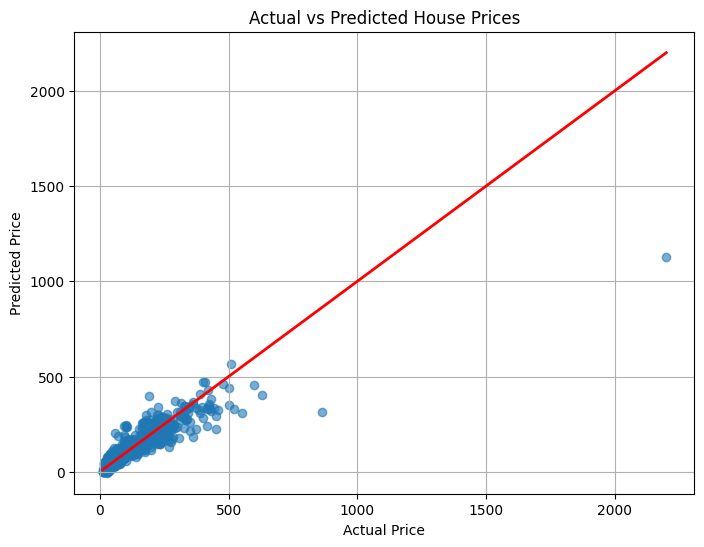

In [ ]:
# ============================================================
# Cell 36 - Actual vs Predicted Plot
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    prediction,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

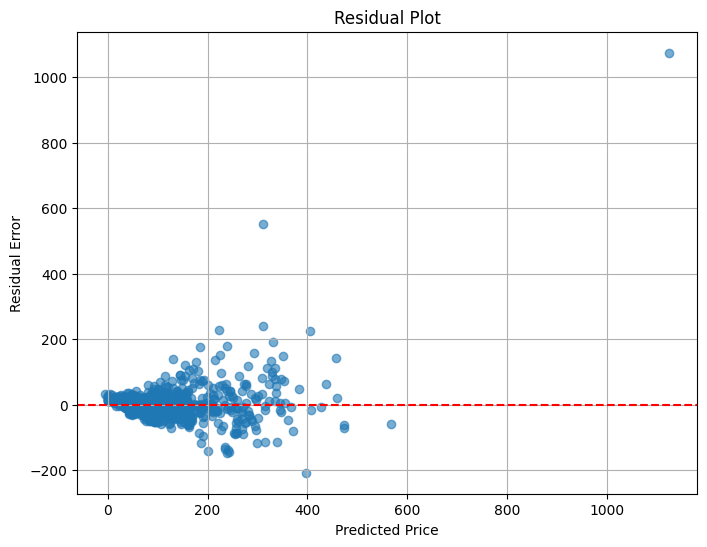

In [ ]:
# ============================================================
# Cell 37 - Residual Plot
# ============================================================

residuals = y_test - prediction

plt.figure(figsize=(8,6))

plt.scatter(
    prediction,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

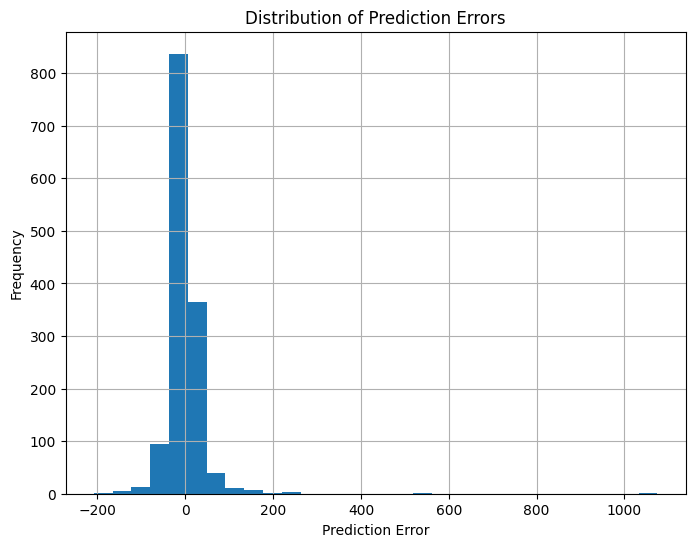

In [ ]:
# ============================================================
# Cell 38 - Error Distribution
# ============================================================

plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# Cell 39 - Final Evaluation
# ============================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

r2 = r2_score(y_test, prediction)
mae = mean_absolute_error(y_test, prediction)
rmse = mean_squared_error(y_test, prediction) ** 0.5
mape = mean_absolute_percentage_error(y_test, prediction)

print("="*45)
print("FINAL MODEL PERFORMANCE")
print("="*45)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAPE     : {mape*100:.2f}%")

FINAL MODEL PERFORMANCE
R² Score : 0.7898
MAE      : 21.0796
RMSE     : 46.4994
MAPE     : 23.75%


In [134]:
import pickle
import json
import os

model_path = os.path.join("..", "..", "backend", "model", "house_price_model.pkl")
columns_path = os.path.join("..", "..", "backend", "model", "columns.json")

with open(model_path, "rb") as f:
    model = pickle.load(f)

with open(columns_path, "r") as f:
    columns = json.load(f)["data_columns"]

print(type(model))
print(len(columns))

print("\nFirst 15 columns:\n")

for i, col in enumerate(columns[:15]):
    print(i, col)

<class 'sklearn.linear_model._base.LinearRegression'>
226

First 15 columns:

0 total_sqft
1 bath
2 balcony
3 bhk
4 1st Phase JP Nagar
5 2nd Phase Judicial Layout
6 5th Phase JP Nagar
7 6th Phase JP Nagar
8 7th Phase JP Nagar
9 8th Phase JP Nagar
10 9th Phase JP Nagar
11 AECS Layout
12 Abbigere
13 Akshaya Nagar
14 Ambalipura
